In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
np.random.seed(26) #Reproducability - Randomness... - ID set
"""
With a seed: The sequence of generated numbers is fixed.
This reproducibility is vital for debugging code, sharing research,
and testing machine learning models consistently.
"""

'\nWith a seed: The sequence of generated numbers is fixed.\nThis reproducibility is vital for debugging code, sharing research, \nand testing machine learning models consistently.\n'

In [6]:
np.random.randint(1, 10)

1

In [7]:
# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Laxminarayen/InceptezGenAI-Batch26/refs/heads/main/18.%20Linear%20Regression%20Hands%20on/IT_Salaries_Dataset.csv")

In [8]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [9]:
df.shape

(3755, 11)

In [10]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [12]:
df['salary_currency'].value_counts()

,count
salary_currency,
USD,3224
EUR,236
GBP,161
INR,60
CAD,25
AUD,9
BRL,6
SGD,6
PLN,5


In [13]:
print(df.isnull().sum()) #One rule of thumb - If my dataset has more than 30% missing values, I dont use it!

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [32]:
null_dataframe = df.isnull().sum()

In [33]:
null_dataframe

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [34]:
null_dataframe = null_dataframe.reset_index()

In [35]:
null_dataframe

,index,0
0,work_year,0
1,experience_level,0
2,employment_type,0
3,job_title,0
4,salary,0
5,salary_currency,0
6,salary_in_usd,0
7,employee_residence,0
8,remote_ratio,0
9,company_location,0


In [36]:
null_dataframe.columns = ['index','values']

In [37]:
null_dataframe

,index,values
0,work_year,0
1,experience_level,0
2,employment_type,0
3,job_title,0
4,salary,0
5,salary_currency,0
6,salary_in_usd,0
7,employee_residence,0
8,remote_ratio,0
9,company_location,0


In [38]:
null_dataframe['missing_percent'] = null_dataframe['values'].apply(lambda x: x/df.shape[0] * 100 )

In [40]:
null_dataframe.set_index('index')

,values,missing_percent
index,,
work_year,0,0.0
experience_level,0,0.0
employment_type,0,0.0
job_title,0,0.0
salary,0,0.0
salary_currency,0,0.0
salary_in_usd,0,0.0
employee_residence,0,0.0
remote_ratio,0,0.0


<Axes: xlabel='index', ylabel='missing_percent'>

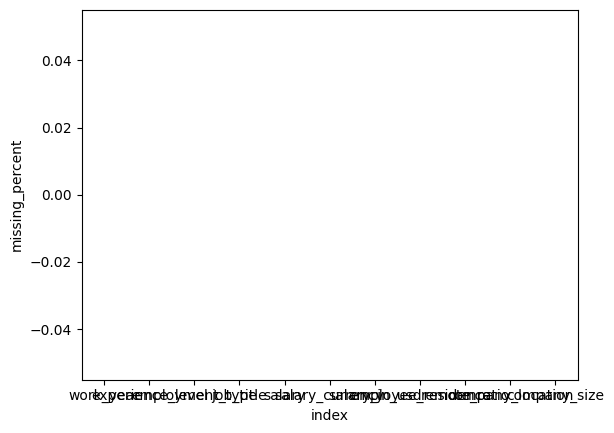

In [41]:
import seaborn as sns
sns.barplot(x = 'index', y = 'missing_percent', data = null_dataframe)

<Axes: >

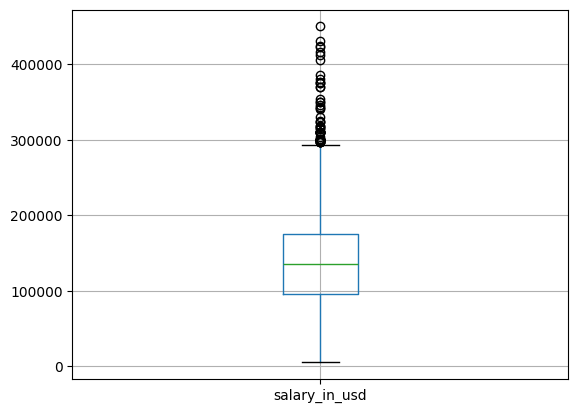

In [43]:
df.boxplot(column="salary_in_usd")

<Axes: title={'center': 'salary_in_usd'}, xlabel='experience_level'>

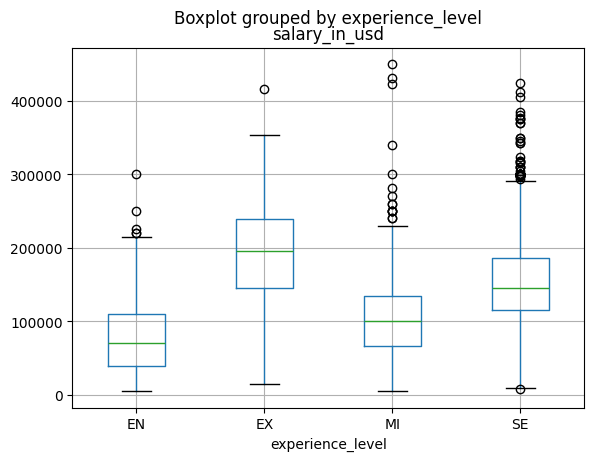

In [42]:
df.boxplot(column="salary_in_usd",by="experience_level")

In [44]:
#Fixed are synthetic prosthetics - they are not real data but
df_preprocessed = df.copy()

df_preprocessed = df_preprocessed.drop_duplicates().reset_index(drop = True)

In [45]:
df_preprocessed.shape

(2584, 11)

<Axes: title={'center': 'salary_in_usd'}, xlabel='experience_level'>

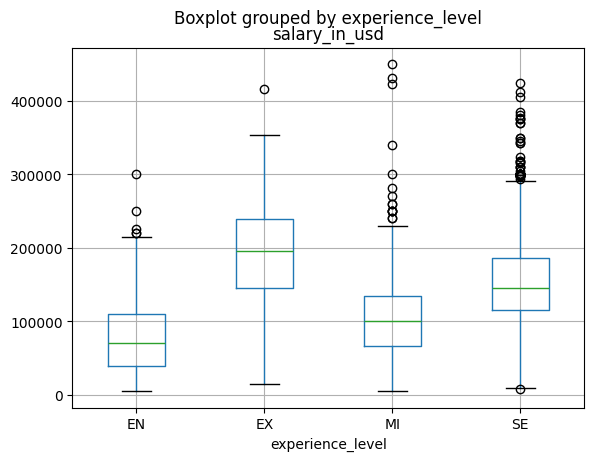

In [46]:
df.boxplot(column="salary_in_usd",by="experience_level")

In [59]:
q1 = df_preprocessed.loc[df_preprocessed['experience_level'] == "SE"]['salary_in_usd'].quantile(0.25)
q3 = df_preprocessed.loc[df_preprocessed['experience_level'] == "SE"]['salary_in_usd'].quantile(0.75)
iqr_se = q3 - q1

np.float64(190150.0)

In [49]:
def iqr_bounds(values):
  q1 = values.quantile(0.25)
  q3 = values.quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  return lower_bound, upper_bound

is_outlier = pd.Series(False,index=df_preprocessed.index) #there are no outliers in the dataset

In [52]:
is_outlier

,0
0,False
1,False
2,False
3,False
4,False
...,...
2579,False
2580,False
2581,False
2582,False


In [57]:
for level, group_salaries in df_preprocessed.groupby('experience_level')['salary_in_usd']:
  print(level)
  lower_bound, upper_bound = iqr_bounds(group_salaries)
  print(lower_bound, upper_bound)
  flagged = (group_salaries < lower_bound) | (group_salaries > upper_bound)
  is_outlier = is_outlier | flagged
  is_outlier.loc[group_salaries.index] = flagged

EN
-70275.0 202165.0
EX
8028.75 371182.75
MI
-44783.125 241269.875
SE
-5225.0 307375.0


In [60]:
is_outlier

,0
0,False
1,False
2,False
3,False
4,False
...,...
2579,True
2580,False
2581,False
2582,False


In [62]:
df_preprocessed = df_preprocessed[~is_outlier].reset_index(drop=True)

In [63]:
df_preprocessed['employee_residence'].value_counts()

,count
employee_residence,
US,1856
GB,149
CA,81
IN,69
ES,47
...,...
RS,1
NZ,1
MD,1


In [64]:
df_preprocessed = df_preprocessed.loc[df_preprocessed['employee_residence']=="US"]

In [65]:
# OrdinalEncoder: we tell it the correct ladder order for each column, and it does the numbering.
experience_encoder = OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX']])
df_preprocessed['ExperienceLevelNum'] = experience_encoder.fit_transform(df_preprocessed[['experience_level']]).ravel()

size_encoder = OrdinalEncoder(categories=[['S', 'M', 'L']])
df_preprocessed['CompanySizeNum'] = size_encoder.fit_transform(df_preprocessed[['company_size']]).ravel()

df_preprocessed[['experience_level', 'ExperienceLevelNum', 'company_size', 'CompanySizeNum']].drop_duplicates().sort_values('ExperienceLevelNum')

/tmp/ipykernel_4026/1866216657.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_preprocessed['ExperienceLevelNum'] = experience_encoder.fit_transform(df_preprocessed[['experience_level']]).ravel()
/tmp/ipykernel_4026/1866216657.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_preprocessed['CompanySizeNum'] = size_encoder.fit_transform(df_preprocessed[['company_size']]).ravel()


,experience_level,ExperienceLevelNum,company_size,CompanySizeNum
13,EN,0.0,L,2.0
90,EN,0.0,M,1.0
685,EN,0.0,S,0.0
18,MI,1.0,M,1.0
143,MI,1.0,L,2.0
1,MI,1.0,S,0.0
9,SE,2.0,M,1.0
5,SE,2.0,L,2.0
767,SE,2.0,S,0.0
55,EX,3.0,M,1.0


In [66]:
# Just for comparison: this is what ONE-HOT encoding would look like instead
# (one 0/1 column per category — useful for categories with NO natural order, like employment_type).
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_example = onehot_encoder.fit_transform(df_preprocessed[['employment_type']].head())

pd.DataFrame(onehot_example, columns=onehot_encoder.get_feature_names_out(['employment_type']))

,employment_type_CT,employment_type_FT
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


In [ ]:
#Normalization / Standardization - Scale / range of independent variables wont be a factor in the prediction

In [67]:
df_preprocessed.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,ExperienceLevelNum,CompanySizeNum
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S,1.0,0.0
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S,1.0,0.0
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L,2.0,2.0
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L,2.0,2.0
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M,2.0,1.0


In [ ]:
# (value - minmum) / (max - min) #MinMax Scaling
# (value) / (max ) #Max scaling
# (value - mu) / sigma # Z- score scaling / normalization

In [68]:
feature_columns = ['ExperienceLevelNum', 'work_year', 'CompanySizeNum']
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_preprocessed[feature_columns] = scaler.fit_transform(df_preprocessed[feature_columns])


/tmp/ipykernel_4026/2256207044.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_preprocessed[feature_columns] = scaler.fit_transform(df_preprocessed[feature_columns])


In [69]:
df_preprocessed.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,ExperienceLevelNum,CompanySizeNum
1,1.0,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S,0.333333,0.0
2,1.0,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S,0.333333,0.0
5,1.0,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L,0.666667,1.0
6,1.0,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L,0.666667,1.0
9,1.0,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M,0.666667,0.5


In [ ]:
# Step 1 - Categorical Encoder - Numerical
# Step 2 - All my numerical features only
# Step 3 - Standardization (Same standardisation for all columns you are going to use)

In [70]:
model_df = df_preprocessed[['ExperienceLevelNum', 'work_year', 'CompanySizeNum', 'salary_in_usd']] #board question? same as training?
#Test question..?

In [71]:
#split - dataframe - Training data - Test data (model will never see to build the line) - Estimate the cost on this unseen data

#Stratified  - Train - test split

In [73]:
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=1) #Random - stratify
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training rows:", len(train_df))
print("Test rows:    ", len(test_df))

Training rows: 1484
Test rows:     372


In [74]:
#Training rows: 1484 #This is to draw the line - B0 and B1
#Found B0 and B1 will be evaluated against test
sklearn_model_1 = LinearRegression() #Predefined Regression model
sklearn_model_1.fit(train_df[['ExperienceLevelNum']], train_df['salary_in_usd'])

#After fitting giving me the best fit
print("Model 1 (Experience Level only):")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_1.intercept_:,.0f} + {sklearn_model_1.coef_[0]:,.0f} × ExperienceLevelNum")

Model 1 (Experience Level only):
  scikit-learn shortcut:  Salary = 92,161 + 102,147 × ExperienceLevelNum


In [75]:
sklearn_model_2 = LinearRegression()
sklearn_model_2.fit(train_df[['ExperienceLevelNum', 'work_year']], train_df['salary_in_usd'])

print("Model 2 (Experience Level + Work Year):")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_2.intercept_:,.0f} + "
      f"{sklearn_model_2.coef_[0]:,.0f} × ExperienceLevelNum + {sklearn_model_2.coef_[1]:,.0f} × work_year")

Model 2 (Experience Level + Work Year):
  scikit-learn shortcut:  Salary = 84,463 + 100,661 × ExperienceLevelNum + 10,583 × work_year


In [76]:
sklearn_model_3 = LinearRegression()
sklearn_model_3.fit(train_df[['ExperienceLevelNum', 'work_year', 'CompanySizeNum']], train_df['salary_in_usd'])

print("Model 3 (Experience Level + Work Year + Company Size):")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_3.intercept_:,.0f} + "
      f"{sklearn_model_3.coef_[0]:,.0f} × ExperienceLevelNum + {sklearn_model_3.coef_[1]:,.0f} × work_year "
      f"+ {sklearn_model_3.coef_[2]:,.0f} × CompanySizeNum")

Model 3 (Experience Level + Work Year + Company Size):
  scikit-learn shortcut:  Salary = 72,391 + 100,615 × ExperienceLevelNum + 14,151 × work_year + 17,037 × CompanySizeNum
